# Lecture 9 - Summarising Data
In this lecture we will look at summarising data in Pandas. The dataset we will be using contains information about domestic flights in Australia. The import is provided below.

In [1]:
import pandas as pd
flights = pd.read_csv('Data/domestic_flights.csv')
flights

,City1,City2,Month,Passenger_Trips,Aircraft_Trips,Route_Distance,Seats
0,ADELAIDE,ALICE SPRINGS,Jan-84,15743,143,1316,19246
1,ADELAIDE,BRISBANE,Jan-84,3781,32,1622,4210
2,ADELAIDE,CANBERRA,Jan-84,1339,12,972,1414
3,ADELAIDE,DARWIN,Jan-84,3050,33,2619,4566
4,ADELAIDE,GOLD COAST,Jan-84,1596,16,1607,1803
...,...,...,...,...,...,...,...
25962,SYDNEY,WAGGA WAGGA,Apr-22,11318,326,367,17244
25963,SYDNEY,WAGGA WAGGA,May-22,12278,351,367,18599
25964,SYDNEY,WAGGA WAGGA,Jun-22,12119,338,367,18116
25965,SYDNEY,WAGGA WAGGA,Jul-22,12863,415,367,20302


In [2]:
flights.dtypes

City1                str
City2                str
Month                str
Passenger_Trips    int64
Aircraft_Trips     int64
Route_Distance     int64
Seats              int64
dtype: object

## Datetime Data
We can see that the dataframe has a 'Month' column that contains datetime information. By default, this is imported as an object (ie. string). We can instead import this as a datetime variable, which means we can easily extract features from the date (eg. month, year). This also means Python will order by Month chonologically rather than alphabetically.

In [6]:
flights = pd.read_csv('Data/domestic_flights.csv', parse_dates = ['Month'], date_format = '%b-%y')
flights

,City1,City2,Month,Passenger_Trips,Aircraft_Trips,Route_Distance,Seats
0,ADELAIDE,ALICE SPRINGS,1984-01-01,15743,143,1316,19246
1,ADELAIDE,BRISBANE,1984-01-01,3781,32,1622,4210
2,ADELAIDE,CANBERRA,1984-01-01,1339,12,972,1414
3,ADELAIDE,DARWIN,1984-01-01,3050,33,2619,4566
4,ADELAIDE,GOLD COAST,1984-01-01,1596,16,1607,1803
...,...,...,...,...,...,...,...
25962,SYDNEY,WAGGA WAGGA,2022-04-01,11318,326,367,17244
25963,SYDNEY,WAGGA WAGGA,2022-05-01,12278,351,367,18599
25964,SYDNEY,WAGGA WAGGA,2022-06-01,12119,338,367,18116
25965,SYDNEY,WAGGA WAGGA,2022-07-01,12863,415,367,20302


Now we would you like you to create the computed columns detailed below. The last two will require you to access datetime methods/attributes.
* Passenger load factor - describes the percentage of seats filled.
* Monthly distance - describes the total distance flown for that month.
* Month name
* Year

In [12]:
# insert code here to add new columns
flights['PLF'] = flights.Passenger_Trips / flights.Seats * 100
flights['Month_Distance'] = flights.Route_Distance * flights.Aircraft_Trips
flights['Month_Name'] = flights.Month.dt.month_name()
flights['Year'] = flights.Month.dt.year
flights

,City1,City2,Month,Passenger_Trips,Aircraft_Trips,Route_Distance,Seats,PLF,Month_Distance,Month_Name,Year
0,ADELAIDE,ALICE SPRINGS,1984-01-01,15743,143,1316,19246,81.798815,188188,January,1984
1,ADELAIDE,BRISBANE,1984-01-01,3781,32,1622,4210,89.809976,51904,January,1984
2,ADELAIDE,CANBERRA,1984-01-01,1339,12,972,1414,94.695898,11664,January,1984
3,ADELAIDE,DARWIN,1984-01-01,3050,33,2619,4566,66.798073,86427,January,1984
4,ADELAIDE,GOLD COAST,1984-01-01,1596,16,1607,1803,88.519135,25712,January,1984
...,...,...,...,...,...,...,...,...,...,...,...
25962,SYDNEY,WAGGA WAGGA,2022-04-01,11318,326,367,17244,65.634424,119642,April,2022
25963,SYDNEY,WAGGA WAGGA,2022-05-01,12278,351,367,18599,66.014302,128817,May,2022
25964,SYDNEY,WAGGA WAGGA,2022-06-01,12119,338,367,18116,66.896666,124046,June,2022
25965,SYDNEY,WAGGA WAGGA,2022-07-01,12863,415,367,20302,63.358290,152305,July,2022


## Aggregates
Last week you looked at how to perform simple aggregates. This week you will explore problems that require more advanced aggregation techniques, such as grouped aggregates and custom aggregates.

Use aggregation to answer the question below:

In [13]:
# What is the total distance flown by all aircraft in the data?
flights.Month_Distance.sum()

np.int64(11488294925)

The total distance flown was 11488294925 km.

In [21]:
# What are the 5 most popular flight routes in the dataframe by total passenger trips?
flights.groupby(['City1', 'City2']).Passenger_Trips.sum().sort_values(ascending=False).head(5)

City1       City2    
MELBOURNE   SYDNEY       210735763
BRISBANE    SYDNEY       124800863
            MELBOURNE     75661129
GOLD COAST  SYDNEY        60226416
ADELAIDE    MELBOURNE     58848582
Name: Passenger_Trips, dtype: int64

In [25]:
# What is the newest flight route in the data?
start_date_by_route = flights.groupby(['City1', 'City2']).Month.min()
max_date = start_date_by_route.max()
start_date_by_route[start_date_by_route==max_date]

City1     City2     
ADELAIDE  CAIRNS       2021-06-01
CAIRNS    GOLD COAST   2021-06-01
Name: Month, dtype: datetime64[us]

In [28]:
# What is the mean and standard deviation of passenger load factor?
flights.PLF.agg(['mean', 'std'])

mean    72.618756
std     11.292801
Name: PLF, dtype: float64

In [30]:
# In what years was passenger load factor at its lowest?
flights.groupby('Year').PLF.mean().sort_values().head()

Year
2021    55.473236
2020    60.712487
1996    69.186924
1997    69.321614
1995    69.648895
Name: PLF, dtype: float64

## Visuals
In pandas you can visualise data with the <code>plot</code> method. This method has lots of potential arguments which can be found here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html. The main ones to consider when starting out are:

<code>x</code>: this is a label that describes what column of the dataframe goes on the x-axis of the plot. Defaults to the index of the series/dataframe.

<code>y</code>: this is a label that describes what column of the dataframe foes on the y-axis of the plot. Defaults to all columns of the series/dataframe.

<code>kind</code>: this is a string describing what type of plot to create. Some notable types are given below:
* 'line' (default)
* 'bar'
* 'barh'
* 'hist'
* 'box'
* 'kde' / 'density'
* 'pie'
* 'scatter'

Use data visuals to answer the following questions:
* How do the total number of passenger trips and seats vary for each month vary with time in the data?
* What percentage of annual flights come in each month of the year?
* What is the relationship between passenger trips and aircraft trips?
* How many people flew on each Brisbane route in 2018?

<Axes: xlabel='Month'>

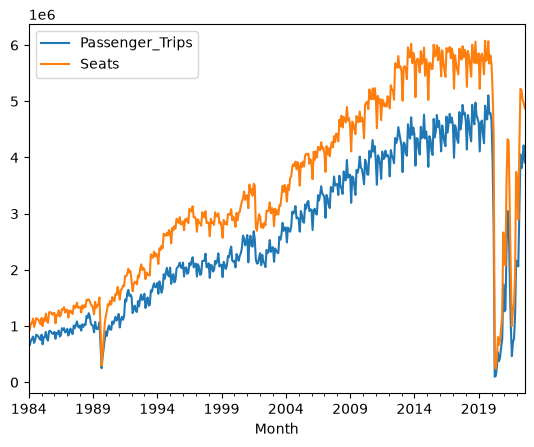

In [32]:
# How do the total number of passenger trips and seats for each month vary with time in the data?
totals_by_month = flights.groupby('Month')[['Passenger_Trips', 'Seats']].sum()
totals_by_month.plot() # line plots are ideal for time-series data (trends with time)

Number steadily increase from 1984 due to 2018, most likely due to population growth in Australia. There is a sudden drop in number from 2019-2021 which was caused by Covid pandemic.

Month_Name
February     423.708796
June         441.336066
January      450.421343
April        451.295736
September    451.582273
November     454.236544
August       457.669542
May          460.172998
July         465.989579
October      466.092019
December     468.163380
March        472.895005
Name: Aircraft_Trips, dtype: float64

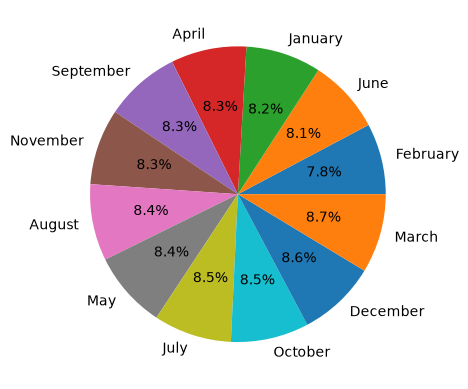

In [37]:
# What percentage of annual flights come in each month of the year?
avg_flights_each_month = flights.groupby('Month_Name').Aircraft_Trips.mean().sort_values()
avg_flights_each_month.plot(kind='pie', autopct='%1.1f%%')
avg_flights_each_month

<Axes: xlabel='Passenger_Trips', ylabel='Aircraft_Trips'>

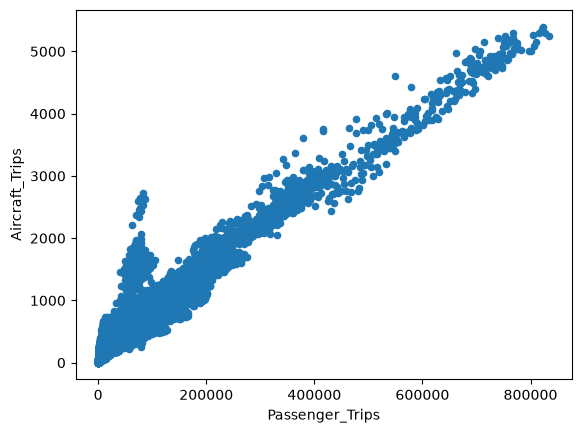

In [40]:
# What is the relationship between passenger trips and aircraft trips?
flights.plot(x='Passenger_Trips', y='Aircraft_Trips', kind='scatter')

In [43]:
flights.corr(numeric_only=True)

,Passenger_Trips,Aircraft_Trips,Route_Distance,Seats,PLF,Month_Distance,Year
Passenger_Trips,1.000000,0.949243,-0.060289,0.995853,0.245743,0.840979,0.126791
Aircraft_Trips,0.949243,1.000000,-0.224587,0.959664,0.124822,0.774902,0.090196
Route_Distance,-0.060289,-0.224587,1.000000,-0.076173,0.258446,0.240118,-0.005282
Seats,0.995853,0.959664,-0.076173,1.000000,0.203973,0.837963,0.123254
PLF,0.245743,0.124822,0.258446,0.203973,1.000000,0.278949,0.005211
Month_Distance,0.840979,0.774902,0.240118,0.837963,0.278949,1.000000,0.134746
Year,0.126791,0.090196,-0.005282,0.123254,0.005211,0.134746,1.000000


In [ ]:
# How many people flew on each Brisbane route in 2018?
# Ran out of time for this question - will do more visuals next lecture though.